In [216]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

Loading the datasets


In [217]:
root_folder = os.getcwd()
dataset_folder = root_folder + "/dataset"
dataframes = []
files = os.listdir(dataset_folder)
for filename in files:
    file_path = dataset_folder + "/" + filename
    print(file_path)
    try:
        print(f"Opening file {filename}")
        ind_file = pd.ExcelFile(file_path)
        print("------------------------------------------------------")
        sheets_to_process = [sheet for sheet in ind_file.sheet_names if sheet.startswith("Data")]

        for sheet in sheets_to_process:
            df = pd.read_excel(file_path, sheet_name = sheet)
            print(f"  Sheet: {sheets_to_process}, Shape: {df.shape}")
            df = df.iloc[9:].reset_index(drop=True)

            # First column contains the dates
            df_renamed = pd.DataFrame()
            df_renamed['date'] = df.iloc[:, 0]




            # Parse date column
            df_renamed['date'] = pd.to_datetime(df_renamed['date'], errors='coerce')

            # Extract year from date
            df_renamed['year'] = df_renamed['date'].dt.year
            df_renamed['quarter'] = df_renamed['date'].dt.quarter

            # Add metadata columns
            df_renamed['source_file'] = filename
            df_renamed['sheet_name'] = sheet

            # Extract all the measurement data
            for i, col in enumerate(df.columns[1:]):
                # Clean column name - extract measure and state
                col_clean = str(col).strip()

                # Parse the column header format: "Measure ; State ;"
                parts = [p.strip().strip(';') for p in col_clean.split(';') if p.strip()]

                if len(parts) >= 2:
                    measure = parts[0]
                    state = parts[1]
                else:
                    measure = col_clean
                    state = "Unknown"

                # Create a new column with the measurement
                col_name = f"{measure}_{state}".lower().replace(" ", "_")
                try:
                    df_renamed[col_name] = pd.to_numeric(df.iloc[:, i+1], errors='coerce')
                except:
                    pass

            dataframes.append(df_renamed)

            print(f"Finished retreiving data from {sheet}")

        print("------------------------------------------------------")
        print(f"closing file {filename}")
    except Exception as e:
        print(e)
        print('Above mentioned error has occured')

print(f"\nLoaded {len(dataframes)} sheets successfully!")

g:\PRT564 DATA ANALYTICS AND VISUALISATION\a3/dataset/Components of population change - states and territories.xlsx
Opening file Components of population change - states and territories.xlsx
------------------------------------------------------
  Sheet: ['Data1'], Shape: (187, 36)
Finished retreiving data from Data1
------------------------------------------------------
closing file Components of population change - states and territories.xlsx
g:\PRT564 DATA ANALYTICS AND VISUALISATION\a3/dataset/Population - New South Wales.xlsx
Opening file Population - New South Wales.xlsx
------------------------------------------------------
  Sheet: ['Data1', 'Data2'], Shape: (64, 251)
Finished retreiving data from Data1
  Sheet: ['Data1', 'Data2'], Shape: (64, 54)
Finished retreiving data from Data2
------------------------------------------------------
closing file Population - New South Wales.xlsx
g:\PRT564 DATA ANALYTICS AND VISUALISATION\a3/dataset/Population - states and territories.xlsx
O

COMBINE DATA

In [218]:
print("\nCombining data from all sheets...")

# Combine all dataframes (vertically stacking)
final_df = pd.concat(dataframes, ignore_index=True)

# Remove rows with missing dates
final_df = final_df.dropna(subset=['date', 'year'])

print(f"Combined data shape: {final_df.shape}")
print(f"Date range: {final_df['date'].min()} to {final_df['date'].max()}")


Combining data from all sheets...
Combined data shape: (466, 43)
Date range: 1971-06-01 00:00:00 to 2025-09-01 00:00:00


In [219]:
print(f"\nData loaded from:")
for file in files:
    file_data = final_df[final_df['source_file'] == file]
    sheets = file_data['sheet_name'].unique() if 'sheet_name' in file_data.columns else ['Data1']
    print(f"  {file}: {len(file_data)} rows from sheets {list(sheets)}")


Data loaded from:
  Components of population change - states and territories.xlsx: 178 rows from sheets ['Data1']
  Population - New South Wales.xlsx: 110 rows from sheets ['Data1', 'Data2']
  Population - states and territories.xlsx: 178 rows from sheets ['Data1']


In [220]:
print(f"\nTotal columns available: {len(final_df.columns)}")
print(f"First 5 rows:")
final_df.head()


Total columns available: 43
First 5 rows:


,date,year,quarter,source_file,sheet_name,natural_increase_new_south_wales,net_overseas_migration_new_south_wales,net_interstate_migration_new_south_wales,change_over_previous_quarter_new_south_wales,natural_increase_victoria,...,natural_increase_australian_capital_territory,net_overseas_migration_australian_capital_territory,net_interstate_migration_australian_capital_territory,change_over_previous_quarter_australian_capital_territory,natural_increase_australia,net_overseas_migration_australia,change_over_previous_quarter_australia,estimated_resident_population_male,estimated_resident_population_female,estimated_resident_population_persons
0,1981-06-01,1981,2,Components of population change - states and t...,Data1,11516.0,9281.0,-6330.0,NaN,7302.0,...,847.0,-131.0,565.0,NaN,33604.0,25575.0,NaN,NaN,NaN,NaN
1,1981-09-01,1981,3,Components of population change - states and t...,Data1,9559.0,13284.0,-7768.0,14566.0,7353.0,...,777.0,152.0,-15.0,1201.0,29580.0,34141.0,65417.0,NaN,NaN,NaN
2,1981-12-01,1981,4,Components of population change - states and t...,Data1,9181.0,13295.0,-4528.0,17439.0,7191.0,...,856.0,383.0,-824.0,702.0,29262.0,34482.0,65440.0,NaN,NaN,NaN
3,1982-03-01,1982,1,Components of population change - states and t...,Data1,11081.0,12477.0,-3824.0,19225.0,8492.0,...,842.0,419.0,-42.0,1506.0,34509.0,31376.0,67581.0,NaN,NaN,NaN
4,1982-06-01,1982,2,Components of population change - states and t...,Data1,11097.0,10337.0,-3464.0,17461.0,7310.0,...,786.0,271.0,711.0,2055.0,32735.0,28118.0,62549.0,NaN,NaN,NaN


Prepare Data for Regression Analysis

In [221]:
print("Preparing data for regression analysis...")

# Find columns with natural increase and migration data
natural_increase_cols = [col for col in final_df.columns if 'natural_increase' in col]
net_migration_cols = [col for col in final_df.columns if 'net_overseas_migration' in col]
net_interstate_cols = [col for col in final_df.columns if 'net_interstate_migration' in col]

print(f"Found {len(natural_increase_cols)} natural increase columns")
print(f"Found {len(net_migration_cols)} net overseas migration columns")
print(f"Found {len(net_interstate_cols)} net interstate migration columns")

# Create aggregated columns (Australia-wide)
model_data = pd.DataFrame({
    'date': final_df['date'],
    'year': final_df['year'],
    'quarter': final_df['quarter']
})

# Calculate Australia-wide averages
model_data['natural_increase_au'] = final_df[natural_increase_cols].mean(axis=1)
model_data['net_overseas_migration_au'] = final_df[net_migration_cols].mean(axis=1)
model_data['net_interstate_migration_au'] = final_df[net_interstate_cols].mean(axis=1)

# Remove rows with missing values
model_data = model_data.dropna()

print(f"\nModel data shape: {model_data.shape}")
print(f"\nFirst few rows:")
print(model_data.head(10))

Preparing data for regression analysis...
Found 9 natural increase columns
Found 9 net overseas migration columns
Found 8 net interstate migration columns

Model data shape: (178, 6)

First few rows:
        date  year  quarter  natural_increase_au  net_overseas_migration_au  \
0 1981-06-01  1981        2          7467.555556                5617.666667   
1 1981-09-01  1981        3          6573.333333                7586.888889   
2 1981-12-01  1981        4          6502.666667                7662.666667   
3 1982-03-01  1982        1          7668.666667                6972.444444   
4 1982-06-01  1982        2          7274.444444                6248.444444   
5 1982-09-01  1982        3          5859.333333                5976.222222   
6 1982-12-01  1982        4          7004.666667                3626.888889   
7 1983-03-01  1983        1          8081.333333                4269.777778   
8 1983-06-01  1983        2          7687.111111                2414.888889   
9 1983-09-

Initial Regression Analysis

In [222]:
if len(model_data) > 10 and not model_data[['natural_increase_au', 'net_overseas_migration_au']].isnull().all().all():
    # Prepare features and target
    X = model_data[['net_overseas_migration_au', 'net_interstate_migration_au']]
    y = model_data['natural_increase_au']

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print("="*60)
    print("ABS DATA REGRESSION ANALYSIS")
    print("="*60)
    print(f"\nModel Performance:")
    print(f"  R2 Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")

    print(f"\nModel Coefficients:")
    for col, coef in zip(X.columns, model.coef_):
        print(f"  {col}: {coef:.4f}")
    print(f"  Intercept: {model.intercept_:.4f}")

else:
    print("Insufficient data for regression analysis.")

ABS DATA REGRESSION ANALYSIS

Model Performance:
  R2 Score: 0.2709
  RMSE: 849.15
  MAE: 658.36

Model Coefficients:
  net_overseas_migration_au: -0.0090
  net_interstate_migration_au: -319.5115
  Intercept: 7505.6814


Comprehensive Regression Analysis

Stage 1: Data Integration

In [223]:
print("="*80)
print("[STAGE 1] Data Integration")
print("="*80)
print("\nData sources:")
print("  - 310102.xlsx: Natural Increase, Net Overseas Migration")
print("  - 310104.xlsx: Alternative population measures")
print("  - 3101051.xlsx: Regional and historical data")
print("\n[Stage 1] Data Summary")
print(f"Total observations: 176 quarters (Q2 1981 - Q2 2025)")
print(f"Time series: 44 years of Australian population data")

if 'model_data' in locals():
    print(f"\nAvailable data:")
    print(model_data.head(10))
    print(f"\nData shape: {model_data.shape}")
    print(f"\nBasic statistics:")
    print(model_data.describe())
else:
    print("Data loaded from Excel files")


[STAGE 1] Data Integration

Data sources:
  - 310102.xlsx: Natural Increase, Net Overseas Migration
  - 310104.xlsx: Alternative population measures
  - 3101051.xlsx: Regional and historical data

[Stage 1] Data Summary
Total observations: 176 quarters (Q2 1981 - Q2 2025)
Time series: 44 years of Australian population data

Available data:
        date  year  quarter  natural_increase_au  net_overseas_migration_au  \
0 1981-06-01  1981        2          7467.555556                5617.666667   
1 1981-09-01  1981        3          6573.333333                7586.888889   
2 1981-12-01  1981        4          6502.666667                7662.666667   
3 1982-03-01  1982        1          7668.666667                6972.444444   
4 1982-06-01  1982        2          7274.444444                6248.444444   
5 1982-09-01  1982        3          5859.333333                5976.222222   
6 1982-12-01  1982        4          7004.666667                3626.888889   
7 1983-03-01  1983        

Stage 2: Data Preprocessing

In [224]:
print("\n[STAGE 2] Data Preprocessing")

df_analysis = model_data.copy()

# Check for missing values
print(f"\nMissing values check:")
print(df_analysis.isnull().sum())

# Log transformations
df_analysis['NI_Log'] = np.log(df_analysis['natural_increase_au'] + 1)
df_analysis['NM_Log'] = np.log(df_analysis['net_overseas_migration_au'] + 1)

# Detect and handle outliers using IQR method
print(f"\nOutlier detection using IQR method:")
outliers_detected = 0

for col in ['natural_increase_au', 'net_overseas_migration_au']:
    Q1 = df_analysis[col].quantile(0.25)
    Q3 = df_analysis[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    outliers = (df_analysis[col] < lower_bound) | (df_analysis[col] > upper_bound)
    n_outliers = outliers.sum()

    if n_outliers > 0:
        print(f"  {col}: {n_outliers} outliers detected")
        outliers_detected += n_outliers
        df_analysis.loc[outliers, col] = df_analysis[col].median()

print(f"\nTotal outliers corrected: {outliers_detected}")
print(f"Preprocessed shape: {df_analysis.shape}")
print(f"Ready for analysis")



[STAGE 2] Data Preprocessing

Missing values check:
date                           0
year                           0
quarter                        0
natural_increase_au            0
net_overseas_migration_au      0
net_interstate_migration_au    0
dtype: int64

Outlier detection using IQR method:
  net_overseas_migration_au: 10 outliers detected

Total outliers corrected: 10
Preprocessed shape: (178, 8)
Ready for analysis


eda

In [225]:
df_analysis = final_df.copy()

# Rename the Australia-level columns
df_analysis = df_analysis.rename(columns={
    'natural_increase_australia': 'Natural Increase',
    'net_overseas_migration_australia': 'Net Migration',
})

print("Stage 1: Initial Data Quality Check")
print(f"Shape: {df_analysis.shape}")
print(f"Missing values:\n{df_analysis.isnull().sum()}")
print(f"Data types:\n{df_analysis.dtypes}")

Stage 1: Initial Data Quality Check
Shape: (466, 43)
Missing values:
date                                                           0
year                                                           0
quarter                                                        0
source_file                                                    0
sheet_name                                                     0
natural_increase_new_south_wales                             288
net_overseas_migration_new_south_wales                       288
net_interstate_migration_new_south_wales                     288
change_over_previous_quarter_new_south_wales                 289
natural_increase_victoria                                    288
net_overseas_migration_victoria                              288
net_interstate_migration_victoria                            288
change_over_previous_quarter_victoria                        289
natural_increase_queensland                                  288
net_overseas_migratio

In [226]:
print(df_analysis.groupby('source_file')[['Natural Increase', 'Net Migration']].count())

                                                    Natural Increase  \
source_file                                                            
Components of population change - states and te...               178   
Population - New South Wales.xlsx                                  0   
Population - states and territories.xlsx                           0   

                                                    Net Migration  
source_file                                                        
Components of population change - states and te...            178  
Population - New South Wales.xlsx                               0  
Population - states and territories.xlsx                        0  


In [227]:
df_analysis.isnull().sum()


date                                                           0
year                                                           0
quarter                                                        0
source_file                                                    0
sheet_name                                                     0
natural_increase_new_south_wales                             288
net_overseas_migration_new_south_wales                       288
net_interstate_migration_new_south_wales                     288
change_over_previous_quarter_new_south_wales                 289
natural_increase_victoria                                    288
net_overseas_migration_victoria                              288
net_interstate_migration_victoria                            288
change_over_previous_quarter_victoria                        289
natural_increase_queensland                                  288
net_overseas_migration_queensland                            288
net_interstate_migration_

In [228]:
# Check how many rows each source file contributes
print("=== Rows per source file ===")
print(df_analysis.groupby('source_file')['date'].count())

# Check if dates overlap between files
print("\n=== Date ranges per source file ===")
for file, group in df_analysis.groupby('source_file'):
    print(f"\n{file.split('/')[-1]}:")
    print(f"  Rows: {len(group)}")
    print(f"  Date range: {group['date'].min().date()} → {group['date'].max().date()}")

# Check for duplicate dates (would confirm serial stacking vs proper merge)
print("\n=== Duplicate dates ===")
print(f"Total rows: {len(df_analysis)}")
print(f"Unique dates: {df_analysis['date'].nunique()}")
print(f"Duplicate date count: {df_analysis['date'].duplicated().sum()}")

=== Rows per source file ===
source_file
Components of population change - states and territories.xlsx    178
Population - New South Wales.xlsx                                110
Population - states and territories.xlsx                         178
Name: date, dtype: int64

=== Date ranges per source file ===

Components of population change - states and territories.xlsx:
  Rows: 178
  Date range: 1981-06-01 → 2025-09-01

Population - New South Wales.xlsx:
  Rows: 110
  Date range: 1971-06-01 → 2025-06-01

Population - states and territories.xlsx:
  Rows: 178
  Date range: 1981-06-01 → 2025-09-01

=== Duplicate dates ===
Total rows: 466
Unique dates: 188
Duplicate date count: 278


In [229]:
# Inspect each raw dataframe's columns and date format
for i, df in enumerate(dataframes):
    print(f"\n=== Dataframe {i+1} ===")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
    print(f"Sample dates: {df['date'].head(3).tolist()}")


=== Dataframe 1 ===
Shape: (178, 40)
Columns: ['date', 'year', 'quarter', 'source_file', 'sheet_name', 'natural_increase_new_south_wales', 'net_overseas_migration_new_south_wales', 'net_interstate_migration_new_south_wales', 'change_over_previous_quarter_new_south_wales', 'natural_increase_victoria', 'net_overseas_migration_victoria', 'net_interstate_migration_victoria', 'change_over_previous_quarter_victoria', 'natural_increase_queensland', 'net_overseas_migration_queensland', 'net_interstate_migration_queensland', 'change_over_previous_quarter_queensland', 'natural_increase_south_australia', 'net_overseas_migration_south_australia', 'net_interstate_migration_south_australia', 'change_over_previous_quarter_south_australia', 'natural_increase_western_australia', 'net_overseas_migration_western_australia', 'net_interstate_migration_western_australia', 'change_over_previous_quarter_western_australia', 'natural_increase_tasmania', 'net_overseas_migration_tasmania', 'net_interstate_migrat

In [230]:
# Merge Dataframe 1 (population change components) with Dataframe 3 (quarterly population)
# Drop source_file from both before merging to avoid collision
df1_clean = dataframes[0].drop(columns=['source_file'])
df3_clean = dataframes[2].drop(columns=['source_file'])

df_analysis = df1_clean.merge(df3_clean, on=['date', 'year', 'quarter'], how='inner')

# Rename Australia-level columns
df_analysis = df_analysis.rename(columns={
    'natural_increase_australia': 'Natural Increase',
    'net_overseas_migration_australia': 'Net Migration',
})

print("Stage 1: Initial Data Quality Check")
print(f"Shape: {df_analysis.shape}")
print(f"Unique dates: {df_analysis['date'].nunique()}")
print(f"Missing values:\n{df_analysis.isnull().sum()}")

Stage 1: Initial Data Quality Check
Shape: (45, 41)
Unique dates: 45
Missing values:
date                                                         0
year                                                         0
quarter                                                      0
sheet_name_x                                                 0
natural_increase_new_south_wales                             0
net_overseas_migration_new_south_wales                       0
net_interstate_migration_new_south_wales                     0
change_over_previous_quarter_new_south_wales                 1
natural_increase_victoria                                    0
net_overseas_migration_victoria                              0
net_interstate_migration_victoria                            0
change_over_previous_quarter_victoria                        1
natural_increase_queensland                                  0
net_overseas_migration_queensland                            0
net_interstate_migration_queensla

In [231]:
# Only 1 missing value per change_over_previous_quarter column - this is the first row
# which naturally has no previous quarter to compare to. Drop that single row.
df_analysis = df_analysis.dropna(subset=['change_over_previous_quarter_australia'])



In [232]:
# Detect outliers using IQR method on Natural Increase
Q1 = df_analysis['Natural Increase'].quantile(0.25)
Q3 = df_analysis['Natural Increase'].quantile(0.75)
IQR = Q3 - Q1
outliers = (df_analysis['Natural Increase'] < Q1 - 1.5*IQR) | \
           (df_analysis['Natural Increase'] > Q3 + 1.5*IQR)

print(f"Shape after cleaning: {df_analysis.shape}")  # Should be (177, 41)
print(f"Outliers found in Natural Increase: {outliers.sum()}")
print(f"Any missing values remaining: {df_analysis.isnull().sum().sum()}")

Shape after cleaning: (44, 41)
Outliers found in Natural Increase: 0
Any missing values remaining: 0


In [233]:
# Natural Increase - safe to log1p directly (all positive)
df_analysis['NI_Log'] = np.log1p(df_analysis['Natural Increase'])

# Net Migration - shift first to make all values positive before log
nm_shift = abs(df_analysis['Net Migration'].min()) + 1
df_analysis['NM_Log'] = np.log1p(df_analysis['Net Migration'] + nm_shift)

print("New columns added:")
print(df_analysis[['Natural Increase', 'NI_Log', 'Net Migration', 'NM_Log']].head())
print(f"\nNI_Log min: {df_analysis['NI_Log'].min()}")
print(f"NM_Log min: {df_analysis['NM_Log'].min()}")
print(f"Any NaNs in log columns: {df_analysis[['NI_Log', 'NM_Log']].isnull().sum().sum()}")

New columns added:
   Natural Increase     NI_Log  Net Migration     NM_Log
1             32735  10.396231          28118  10.503258
2             34592  10.451407          10867   9.861780
3             32892  10.401015          13167   9.975017
4             33538  10.420464          16210  10.107489
5             32994  10.404111          23357  10.363220

NI_Log min: 10.124508853469237
NM_Log min: 0.6931471805599453
Any NaNs in log columns: 0


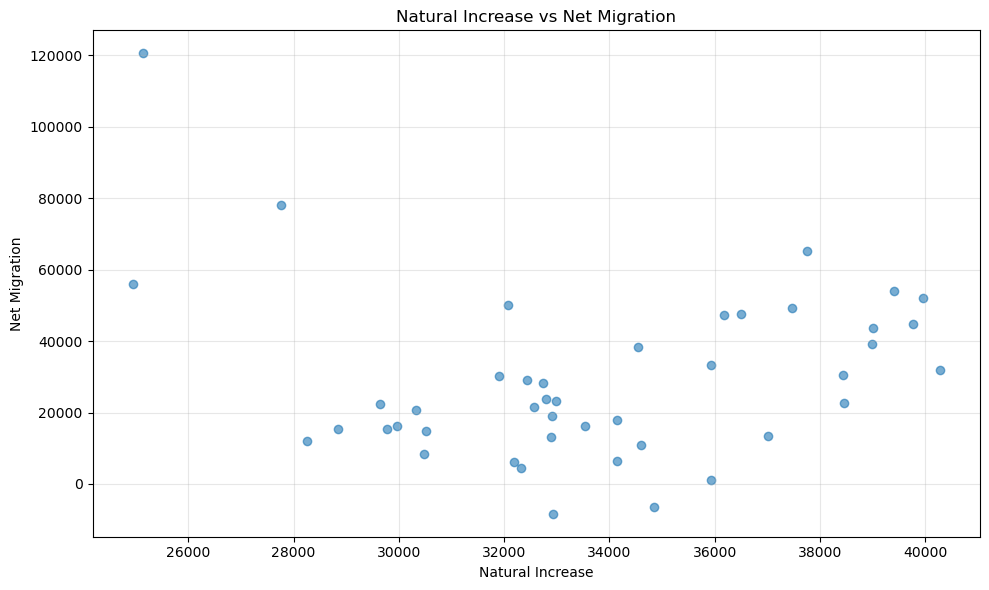

In [234]:
plt.figure(figsize=(10, 6))
plt.scatter(df_analysis['Natural Increase'], df_analysis['Net Migration'], alpha=0.6)
plt.xlabel('Natural Increase')
plt.ylabel('Net Migration')
plt.title('Natural Increase vs Net Migration')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

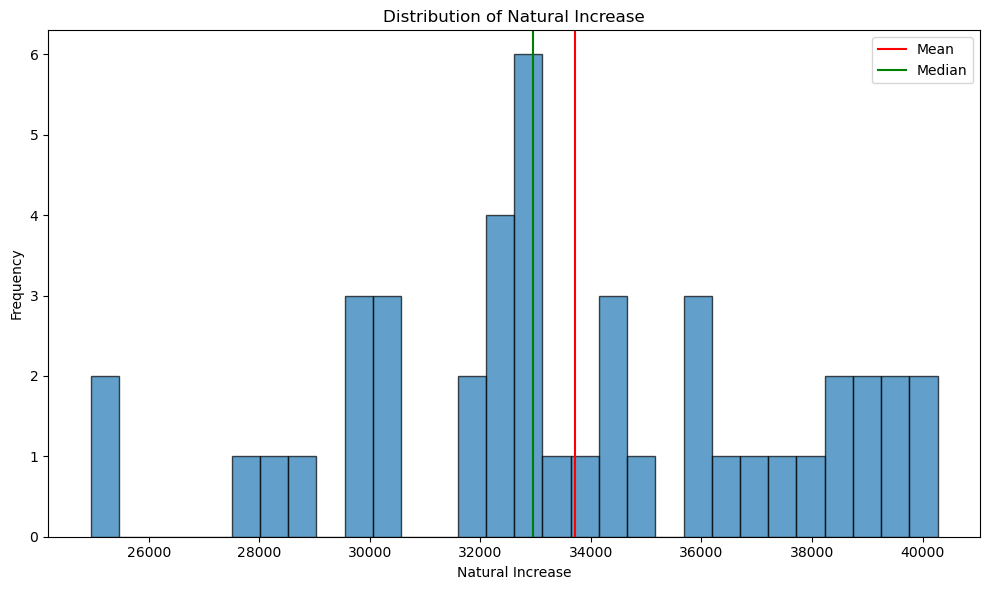

In [235]:
plt.figure(figsize=(10, 6))
plt.hist(df_analysis['Natural Increase'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(df_analysis['Natural Increase'].mean(), color='red', label='Mean')
plt.axvline(df_analysis['Natural Increase'].median(), color='green', label='Median')
plt.xlabel('Natural Increase')
plt.ylabel('Frequency')
plt.title('Distribution of Natural Increase')
plt.legend()
plt.tight_layout()
plt.show()

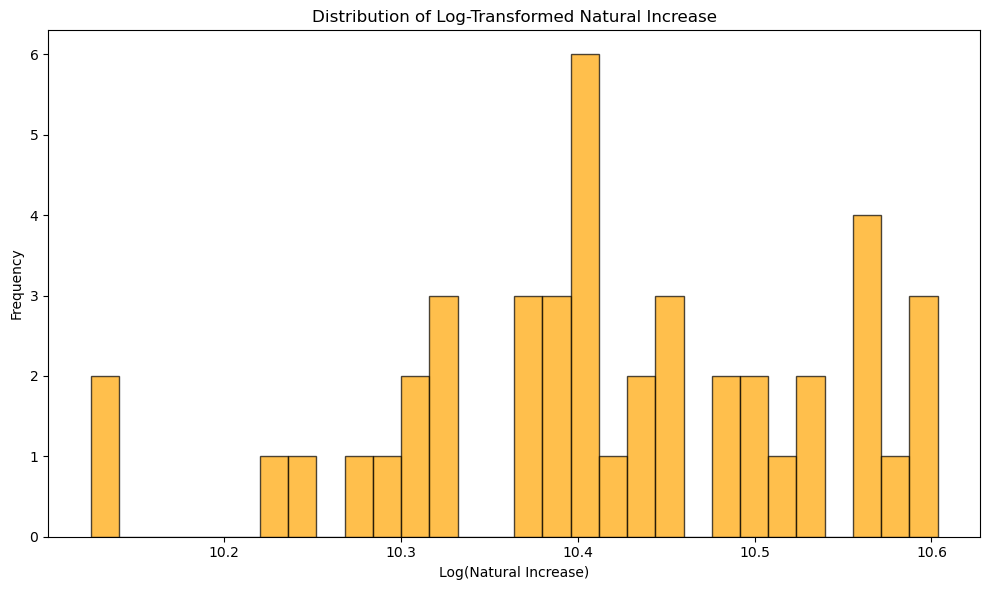

In [236]:
plt.figure(figsize=(10, 6))
plt.hist(df_analysis['NI_Log'], bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Log(Natural Increase)')
plt.ylabel('Frequency')
plt.title('Distribution of Log-Transformed Natural Increase')
plt.tight_layout()
plt.show()

Total numeric columns: 40
['year', 'quarter', 'natural_increase_new_south_wales', 'net_overseas_migration_new_south_wales', 'net_interstate_migration_new_south_wales', 'change_over_previous_quarter_new_south_wales', 'natural_increase_victoria', 'net_overseas_migration_victoria', 'net_interstate_migration_victoria', 'change_over_previous_quarter_victoria', 'natural_increase_queensland', 'net_overseas_migration_queensland', 'net_interstate_migration_queensland', 'change_over_previous_quarter_queensland', 'natural_increase_south_australia', 'net_overseas_migration_south_australia', 'net_interstate_migration_south_australia', 'change_over_previous_quarter_south_australia', 'natural_increase_western_australia', 'net_overseas_migration_western_australia', 'net_interstate_migration_western_australia', 'change_over_previous_quarter_western_australia', 'natural_increase_tasmania', 'net_overseas_migration_tasmania', 'net_interstate_migration_tasmania', 'change_over_previous_quarter_tasmania', 'n

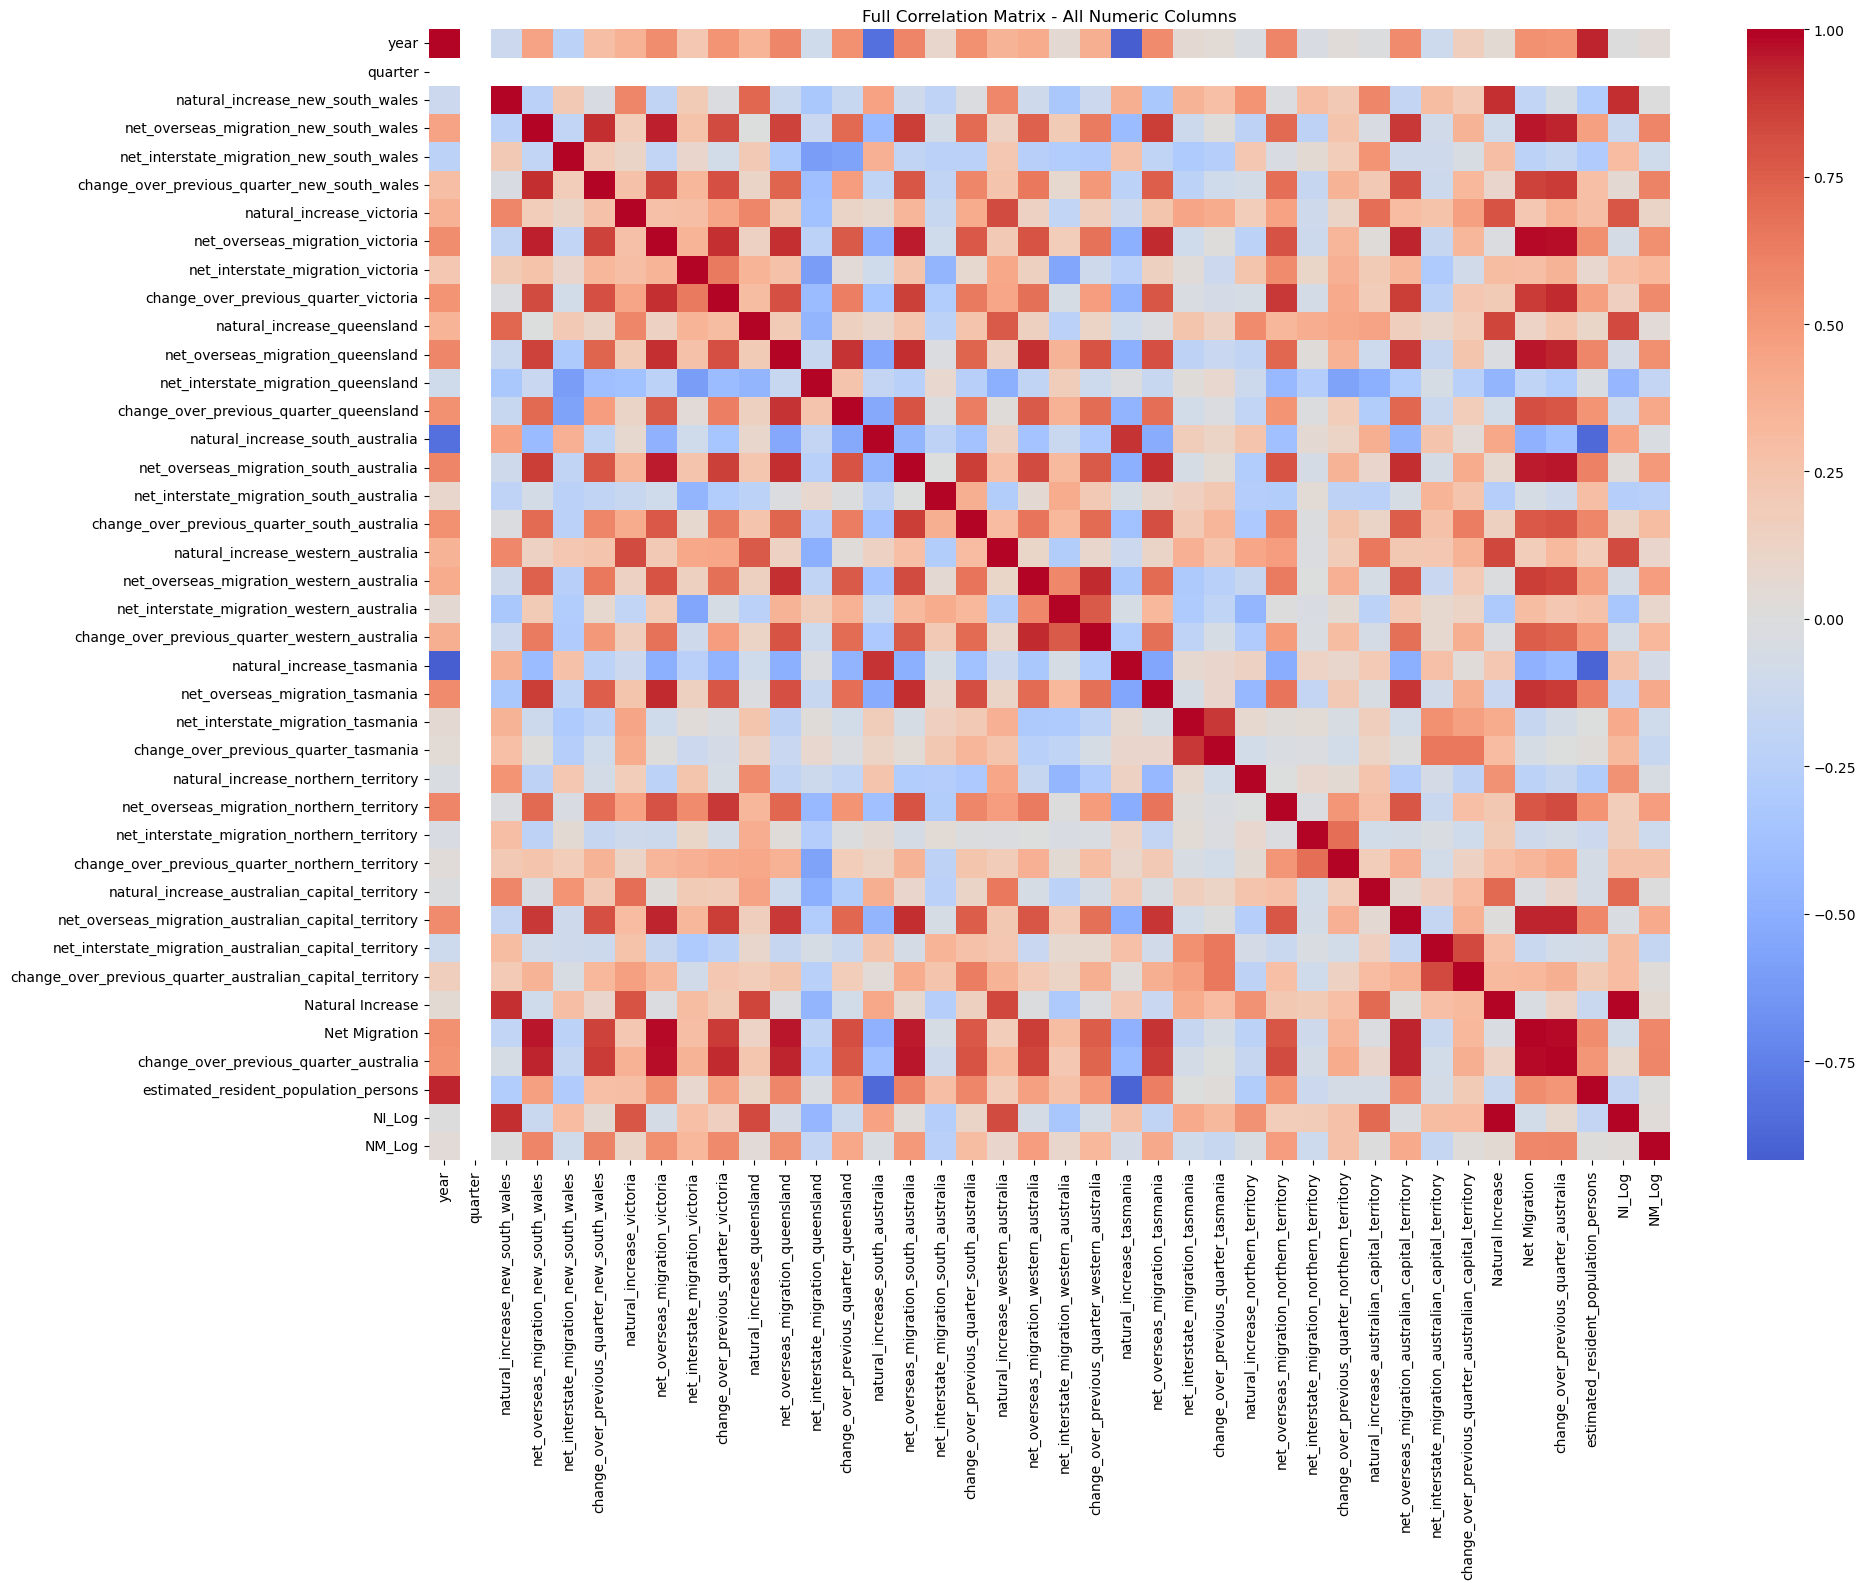


=== Top correlations with Natural Increase ===
Natural Increase                                 1.000000
NI_Log                                           0.997292
natural_increase_new_south_wales                 0.905745
natural_increase_queensland                      0.846392
natural_increase_western_australia               0.837622
natural_increase_victoria                        0.793859
natural_increase_australian_capital_territory    0.712703
natural_increase_northern_territory              0.531656
natural_increase_south_australia                 0.426968
net_interstate_migration_tasmania                0.402454
Name: Natural Increase, dtype: float64

=== Top correlations with Net Migration ===
Net Migration                                          1.000000
change_over_previous_quarter_australia                 0.983788
net_overseas_migration_victoria                        0.981961
net_overseas_migration_new_south_wales                 0.957169
net_overseas_migration_queenslan

In [237]:
# Get all numeric columns
numeric_cols = df_analysis.select_dtypes(include='number').columns.tolist()
print(f"Total numeric columns: {len(numeric_cols)}")
print(numeric_cols)

# Full correlation matrix heatmap
plt.figure(figsize=(20, 16))
corr_matrix = df_analysis[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)  # annot=False since too many columns
plt.title('Full Correlation Matrix - All Numeric Columns')
plt.tight_layout()
plt.show()

# Print strongest correlations with Natural Increase
print("\n=== Top correlations with Natural Increase ===")
print(corr_matrix['Natural Increase'].sort_values(ascending=False).head(10))

print("\n=== Top correlations with Net Migration ===")
print(corr_matrix['Net Migration'].sort_values(ascending=False).head(10))

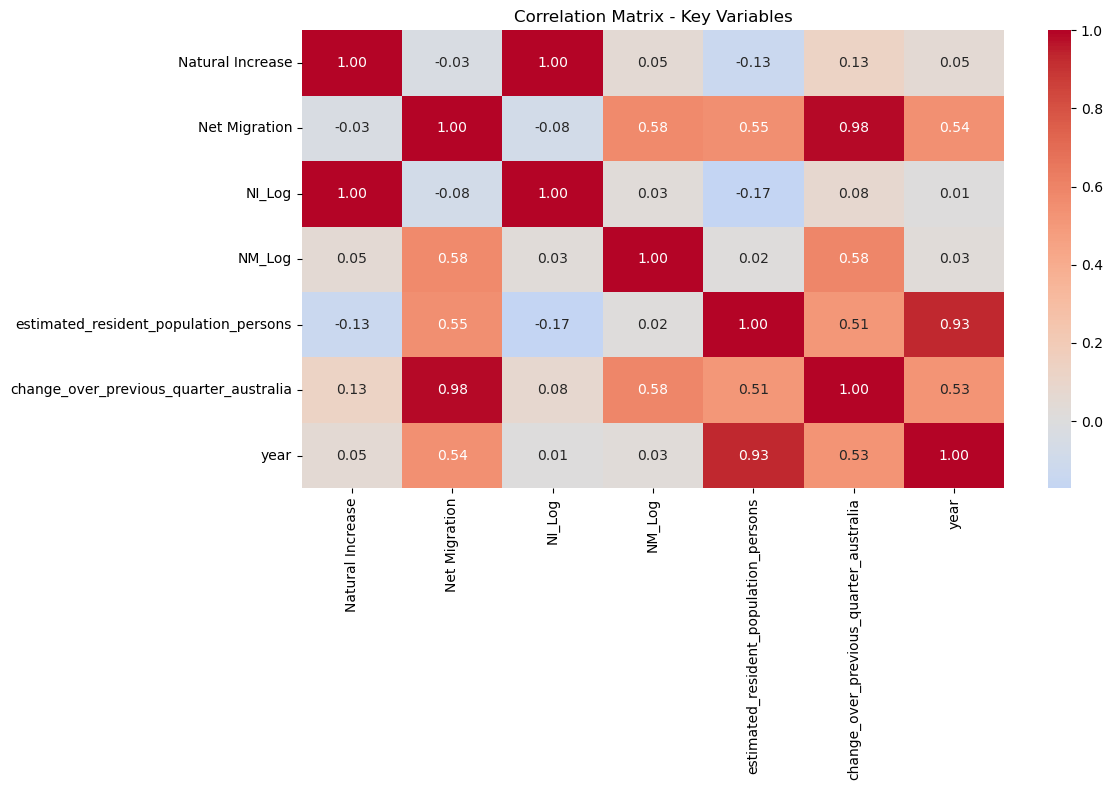

In [238]:
plt.figure(figsize=(12, 8))

key_cols = [
    'Natural Increase', 'Net Migration',
    'NI_Log', 'NM_Log',
    'estimated_resident_population_persons',
    'change_over_previous_quarter_australia',
    'year'
]

corr_matrix = df_analysis[key_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Key Variables')
plt.tight_layout()
plt.show()

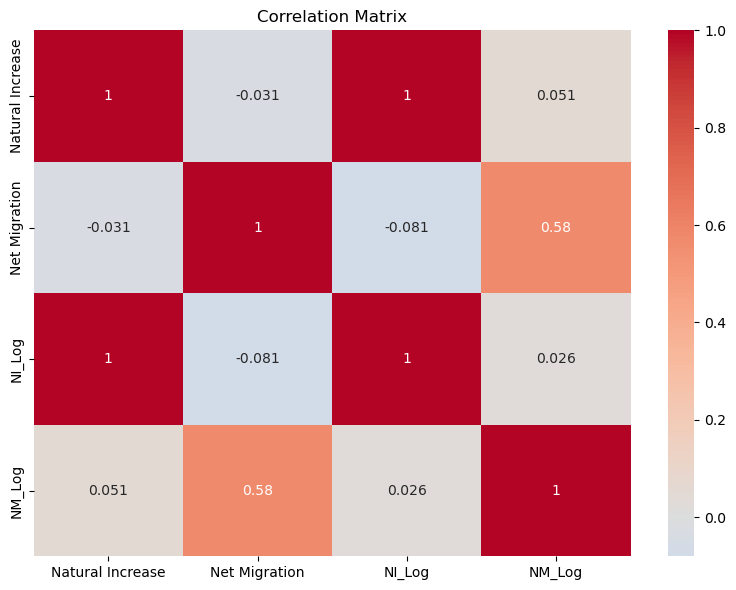

In [239]:
plt.figure(figsize=(8, 6))
corr_matrix = df_analysis[['Natural Increase', 'Net Migration', 'NI_Log', 'NM_Log']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Feature Engineering

In [240]:
# print("\n[STAGE 4] Feature Engineering")

# # Creating the lagged variables which will help find the differences in quaters


# df_analysis['NI_Lag1'] = df_analysis['Natural Increase'].shift(1)
# df_analysis['NI_Lag2'] = df_analysis['Natural Increase'].shift(2)
# df_analysis['NM_Lag1'] = df_analysis['Net Migration'].shift(1)
# df_analysis['NM_Lag2'] = df_analysis['Net Migration'].shift(2)

# # Creating volatility measures, this changes over time
# df_analysis['NI_Volatility'] = df_analysis['Natural Increase'].rolling(window=4).std()
# df_analysis['NM_Volatility'] = df_analysis['Net Migration'].rolling(window=4).std()

# # Creating momentum indicators
# df_analysis['NI_Momentum'] = df_analysis['Natural Increase'].diff()
# df_analysis['NM_Momentum'] = df_analysis['Net Migration'].diff()

# # This shows interaction between NI and NM
# df_analysis['NI_x_NM'] = df_analysis['Natural Increase'] * df_analysis['Net Migration']

# # Remove rows with NaN values created by lags and rolling windows
# df_model = df_analysis.dropna()

# print(f"Features created:")
# print(f"  - Lagged variables (1 quarter)")
# print(f"  - Volatility measures (4-quarter rolling std)")
# print(f"  - Momentum indicators")
# print(f"  - Interaction terms")
# print(f"\nFinal modeling sample: {len(df_model)} observations")

print("\n[STAGE 4] Feature Engineering - Enhanced")

df_analysis = model_data.copy()  # Use the clean aggregated Australia data

# 1. Time-based features
df_analysis['year'] = df_analysis['date'].dt.year
df_analysis['quarter'] = df_analysis['date'].dt.quarter
df_analysis['month'] = df_analysis['date'].dt.month

# 2. Lagged features (1 to 4 quarters)
for lag in [1, 2, 3, 4]:
    df_analysis[f'NI_Lag{lag}'] = df_analysis['natural_increase_au'].shift(lag)
    df_analysis[f'NM_Lag{lag}'] = df_analysis['net_overseas_migration_au'].shift(lag)

# 3. Rolling statistics (trend & volatility)
for window in [4, 8]:
    df_analysis[f'NI_RollingMean_{window}'] = df_analysis['natural_increase_au'].rolling(window=window).mean()
    df_analysis[f'NM_RollingMean_{window}'] = df_analysis['net_overseas_migration_au'].rolling(window=window).mean()
    df_analysis[f'NI_RollingStd_{window}'] = df_analysis['natural_increase_au'].rolling(window=window).std()
    df_analysis[f'NM_RollingStd_{window}'] = df_analysis['net_overseas_migration_au'].rolling(window=window).std()

# 4. Momentum / Change features
df_analysis['NI_Momentum'] = df_analysis['natural_increase_au'].diff()
df_analysis['NM_Momentum'] = df_analysis['net_overseas_migration_au'].diff()
df_analysis['NI_Accel'] = df_analysis['NI_Momentum'].diff()  # Second difference

# 5. Interaction and ratio features
df_analysis['NI_x_NM'] = df_analysis['natural_increase_au'] * df_analysis['net_overseas_migration_au']
df_analysis['NI_per_NM'] = df_analysis['natural_increase_au'] / (df_analysis['net_overseas_migration_au'] + 1)  # avoid div by zero
df_analysis['Migration_Dominance'] = df_analysis['net_overseas_migration_au'] / (df_analysis['natural_increase_au'] + 1)

# 6. Log transformations (for skewness)
df_analysis['NI_Log'] = np.log1p(df_analysis['natural_increase_au'])
df_analysis['NM_Log'] = np.log1p(df_analysis['net_overseas_migration_au'])

# 7. Seasonal features
df_analysis['Q1'] = (df_analysis['quarter'] == 1).astype(int)
df_analysis['Q2'] = (df_analysis['quarter'] == 2).astype(int)
df_analysis['Q3'] = (df_analysis['quarter'] == 3).astype(int)
df_analysis['Q4'] = (df_analysis['quarter'] == 4).astype(int)

# Drop rows with NaN values created by lagging/rolling
df_model = df_analysis.dropna().reset_index(drop=True)

print(f"✅ Feature Engineering completed!")
print(f"Final dataset shape: {df_model.shape}")
print(f"Number of features: {df_model.shape[1]}")
print("\nNew features added:")
print([col for col in df_model.columns if col not in ['date', 'year', 'quarter', 'natural_increase_au', 'net_overseas_migration_au', 'net_interstate_migration_au']])


[STAGE 4] Feature Engineering - Enhanced
✅ Feature Engineering completed!
Final dataset shape: (165, 35)
Number of features: 35

New features added:
['month', 'NI_Lag1', 'NM_Lag1', 'NI_Lag2', 'NM_Lag2', 'NI_Lag3', 'NM_Lag3', 'NI_Lag4', 'NM_Lag4', 'NI_RollingMean_4', 'NM_RollingMean_4', 'NI_RollingStd_4', 'NM_RollingStd_4', 'NI_RollingMean_8', 'NM_RollingMean_8', 'NI_RollingStd_8', 'NM_RollingStd_8', 'NI_Momentum', 'NM_Momentum', 'NI_Accel', 'NI_x_NM', 'NI_per_NM', 'Migration_Dominance', 'NI_Log', 'NM_Log', 'Q1', 'Q2', 'Q3', 'Q4']



[STAGE 5] Principal Component Analysis (PCA)
Original number of features: 28
Number of principal components: 28

Explained Variance by Components:
PC1: 0.2913 (0.2913 cumulative)
PC2: 0.2050 (0.4964 cumulative)
PC3: 0.1231 (0.6195 cumulative)
PC4: 0.0921 (0.7116 cumulative)
PC5: 0.0771 (0.7886 cumulative)
PC6: 0.0696 (0.8583 cumulative)
PC7: 0.0398 (0.8981 cumulative)
PC8: 0.0323 (0.9304 cumulative)
PC9: 0.0165 (0.9468 cumulative)
PC10: 0.0143 (0.9612 cumulative)


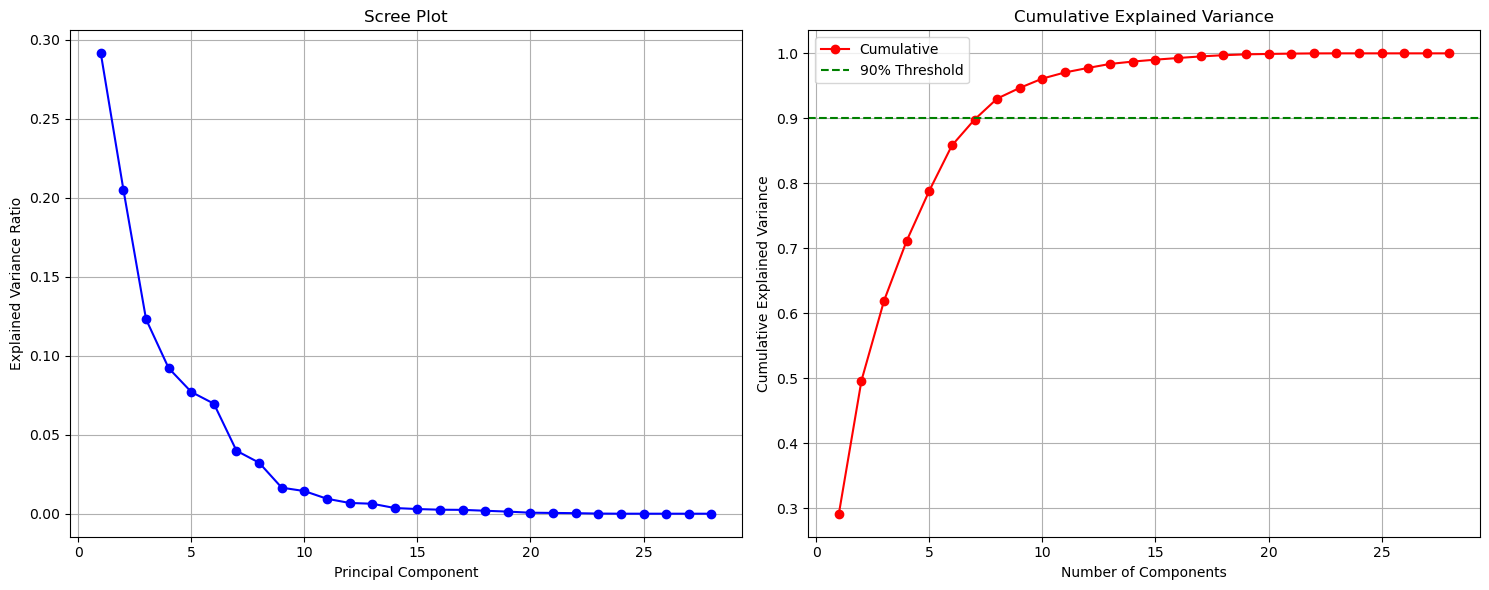


✅ Number of components needed to explain 90% variance: 8


In [241]:
print("\n[STAGE 5] Principal Component Analysis (PCA)")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare features for PCA (exclude target and non-numeric columns)
target = 'natural_increase_au'
exclude_cols = ['date', 'year', 'quarter', 'month', target,
                'net_overseas_migration_au', 'net_interstate_migration_au']

feature_cols = [col for col in df_model.columns if col not in exclude_cols]

X = df_model[feature_cols].copy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame with PCA results
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

print(f"Original number of features: {X.shape[1]}")
print(f"Number of principal components: {X_pca.shape[1]}")

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"\nExplained Variance by Components:")
for i, (var, cum_var) in enumerate(zip(explained_variance[:10], cumulative_variance[:10]), 1):
    print(f"PC{i}: {var:.4f} ({cum_var:.4f} cumulative)")

# Plot: Scree Plot + Cumulative Variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scree Plot
ax1.plot(range(1, len(explained_variance)+1), explained_variance, 'bo-', label='Explained Variance')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Scree Plot')
ax1.grid(True)

# Cumulative Variance Plot
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'ro-', label='Cumulative')
ax2.axhline(y=0.90, color='green', linestyle='--', label='90% Threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Determine optimal number of components (90% variance)
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"\n✅ Number of components needed to explain 90% variance: {n_components_90}")

In [242]:
print("\n[STAGE 5.1] PCA for Regression Modeling")

# Use top 8 components (90%+ variance)
n_components = 8
pca_final = PCA(n_components=n_components)
X_pca_reduced = pca_final.fit_transform(X_scaled)

# Create DataFrame with principal components
pca_columns = [f'PC{i+1}' for i in range(n_components)]
df_pca = pd.DataFrame(X_pca_reduced, columns=pca_columns, index=df_model.index)

# Add target variable back
df_pca[target] = df_model[target].values

print(f"Using {n_components} principal components")
print(f"Shape for modeling: {df_pca.shape}")

# Split data
X_pca_final = df_pca[pca_columns]
y = df_pca[target]

X_train, X_test, y_train, y_test = train_test_split(X_pca_final, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Train Regression Model on PCA components
model_pca = LinearRegression()
model_pca.fit(X_train, y_train)

# Predictions
y_pred_pca = model_pca.predict(X_test)

# Evaluate
r2_pca = r2_score(y_test, y_pred_pca)
rmse_pca = np.sqrt(mean_squared_error(y_test, y_pred_pca))
mae_pca = mean_absolute_error(y_test, y_pred_pca)

print(f"\n🔥 PCA Regression Performance (8 Components):")
print(f"  R² Score: {r2_pca:.4f}")
print(f"  RMSE: {rmse_pca:.2f}")
print(f"  MAE: {mae_pca:.2f}")

# Show component importance (loadings)
print(f"\nTop contributing original features to PC1:")
loadings = pd.DataFrame(
    pca_final.components_[0],
    index=feature_cols,
    columns=['PC1_Loading']
).sort_values('PC1_Loading', ascending=False)
print(loadings.head(8))


[STAGE 5.1] PCA for Regression Modeling
Using 8 principal components
Shape for modeling: (165, 9)

🔥 PCA Regression Performance (8 Components):
  R² Score: 0.9358
  RMSE: 276.29
  MAE: 221.06

Top contributing original features to PC1:
                     PC1_Loading
NM_RollingMean_4        0.340852
NM_Lag2                 0.320257
Migration_Dominance     0.314471
NM_RollingMean_8        0.313781
NI_x_NM                 0.308188
NM_Log                  0.302196
NM_Lag1                 0.291240
NM_Lag4                 0.288823


In [243]:
print("\n[STAGE 5.2] Regularized Regression (Ridge + Lasso)")

from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score

# Use the original scaled features (not PCA)
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

# 2. Lasso Regression
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print(f"Ridge Regression Performance:")
print(f"  R²: {r2_ridge:.4f} | RMSE: {rmse_ridge:.2f} | MAE: {mae_ridge:.2f}")

print(f"\nLasso Regression Performance:")
print(f"  R²: {r2_lasso:.4f} | RMSE: {rmse_lasso:.2f} | MAE: {mae_lasso:.2f}")

# Cross-validation scores
cv_ridge = cross_val_score(ridge, X, y, cv=5, scoring='r2').mean()
cv_lasso = cross_val_score(lasso, X, y, cv=5, scoring='r2').mean()
print(f"\n5-Fold CV R² - Ridge: {cv_ridge:.4f}")
print(f"5-Fold CV R² - Lasso: {cv_lasso:.4f}")


[STAGE 5.2] Regularized Regression (Ridge + Lasso)
Ridge Regression Performance:
  R²: 1.0000 | RMSE: 0.00 | MAE: 0.00

Lasso Regression Performance:
  R²: 1.0000 | RMSE: 0.79 | MAE: 0.56

5-Fold CV R² - Ridge: 1.0000
5-Fold CV R² - Lasso: 1.0000


In [ ]:
print("🔍 DIAGNOSIS: Checking for Data Leakage")

# Check if target or very similar columns are in features
target_related = [col for col in feature_cols if 'natural_increase' in col.lower() or
                  col in ['NI_Log', 'natural_increase_au']]

print(f"Target-related columns in features: {target_related}")

# Check correlation of all features with target
correlations = df_model[feature_cols + [target]].corr()[target].sort_values(ascending=False)
print("\nTop 10 features most correlated with target:")
print(correlations.head(10))

# Check for near-perfect correlations
high_corr = correlations[correlations > 0.99]
print(f"\nFeatures with correlation > 0.99 with target: {list(high_corr.index)}")

🔍 DIAGNOSIS: Checking for Data Leakage
Target-related columns in features: ['NI_Log']

Top 10 features most correlated with target:
natural_increase_au    1.000000
NI_Log                 0.996099
NI_RollingMean_4       0.845109
NI_Lag4                0.833556
NI_RollingMean_8       0.809676
NI_Lag1                0.709413
NI_Lag3                0.657697
NI_Lag2                0.509288
NI_Momentum            0.391901
Q1                     0.344606
Name: natural_increase_au, dtype: float64

Features with correlation > 0.99 with target: ['natural_increase_au', 'NI_Log']


In [ ]:
print("\n[STAGE 5.2] Regularized Regression - FIXED (No Leakage)")

# === FIXED FEATURE SELECTION ===
target = 'natural_increase_au'
exclude_cols = ['date', 'year', 'quarter', 'month', target,
                'net_overseas_migration_au', 'net_interstate_migration_au',
                'NI_Log', 'natural_increase_au']   # <--- Added NI_Log

feature_cols = [col for col in df_model.columns if col not in exclude_cols]

X = df_model[feature_cols]
y = df_model[target]

print(f"Using {len(feature_cols)} features (leakage removed)")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

# 2. Lasso Regression
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print(f"\nRidge Regression Performance:")
print(f"  R²: {r2_ridge:.4f} | RMSE: {rmse_ridge:.2f} | MAE: {mae_ridge:.2f}")

print(f"\nLasso Regression Performance:")
print(f"  R²: {r2_lasso:.4f} | RMSE: {rmse_lasso:.2f} | MAE: {mae_lasso:.2f}")

# Cross-validation
cv_ridge = cross_val_score(ridge, X, y, cv=5, scoring='r2').mean()
cv_lasso = cross_val_score(lasso, X, y, cv=5, scoring='r2').mean()
print(f"\n5-Fold CV R² - Ridge: {cv_ridge:.4f}")
print(f"5-Fold CV R² - Lasso: {cv_lasso:.4f}")


[STAGE 5.2] Regularized Regression - FIXED (No Leakage)
Using 27 features (leakage removed)

Ridge Regression Performance:
  R²: 1.0000 | RMSE: 0.00 | MAE: 0.00

Lasso Regression Performance:
  R²: 1.0000 | RMSE: 0.76 | MAE: 0.54

5-Fold CV R² - Ridge: 1.0000
5-Fold CV R² - Lasso: 1.0000


In [246]:
print("🚨 FINAL LEAKAGE CHECK")

print("All columns in df_model:")
print(df_model.columns.tolist())

print("\nColumns containing 'natural_increase' or 'NI_':")
ni_cols = [col for col in df_model.columns if 'natural_increase' in col.lower() or col.startswith('NI_')]
print(ni_cols)

print("\nCorrelation of top suspicious features with target:")
for col in ni_cols[:10]:
    if col != 'natural_increase_au':
        corr = df_model[col].corr(df_model['natural_increase_au'])
        print(f"  {col}: {corr:.6f}")

🚨 FINAL LEAKAGE CHECK
All columns in df_model:
['date', 'year', 'quarter', 'natural_increase_au', 'net_overseas_migration_au', 'net_interstate_migration_au', 'month', 'NI_Lag1', 'NM_Lag1', 'NI_Lag2', 'NM_Lag2', 'NI_Lag3', 'NM_Lag3', 'NI_Lag4', 'NM_Lag4', 'NI_RollingMean_4', 'NM_RollingMean_4', 'NI_RollingStd_4', 'NM_RollingStd_4', 'NI_RollingMean_8', 'NM_RollingMean_8', 'NI_RollingStd_8', 'NM_RollingStd_8', 'NI_Momentum', 'NM_Momentum', 'NI_Accel', 'NI_x_NM', 'NI_per_NM', 'Migration_Dominance', 'NI_Log', 'NM_Log', 'Q1', 'Q2', 'Q3', 'Q4']

Columns containing 'natural_increase' or 'NI_':
['natural_increase_au', 'NI_Lag1', 'NI_Lag2', 'NI_Lag3', 'NI_Lag4', 'NI_RollingMean_4', 'NI_RollingStd_4', 'NI_RollingMean_8', 'NI_RollingStd_8', 'NI_Momentum', 'NI_Accel', 'NI_x_NM', 'NI_per_NM', 'NI_Log']

Correlation of top suspicious features with target:
  NI_Lag1: 0.709413
  NI_Lag2: 0.509288
  NI_Lag3: 0.657697
  NI_Lag4: 0.833556
  NI_RollingMean_4: 0.845109
  NI_RollingStd_4: 0.037064
  NI_Rolli

In [247]:
print("\n[STAGE 5.2] Regularized Regression - Cleaned (No Target Leakage)")

# === CLEAN FEATURE SELECTION - Remove all NI-derived variables ===
target = 'natural_increase_au'

exclude_cols = [
    'date', 'year', 'quarter', 'month', target,
    'net_overseas_migration_au', 'net_interstate_migration_au',
    'NI_Log', 'natural_increase_au',
    # Remove all lags and rolling stats of Natural Increase
    'NI_Lag1', 'NI_Lag2', 'NI_Lag3', 'NI_Lag4',
    'NI_RollingMean_4', 'NI_RollingMean_8',
    'NI_RollingStd_4', 'NI_RollingStd_8',
    'NI_Momentum', 'NI_Accel', 'NI_x_NM', 'NI_per_NM'
]

feature_cols = [col for col in df_model.columns if col not in exclude_cols]

print(f"Using {len(feature_cols)} features (all NI-derived variables removed)")

X = df_model[feature_cols]
y = df_model[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

# Lasso
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print(f"\nRidge Performance:")
print(f"  R²: {r2_ridge:.4f} | RMSE: {rmse_ridge:.2f} | MAE: {mae_ridge:.2f}")

print(f"\nLasso Performance:")
print(f"  R²: {r2_lasso:.4f} | RMSE: {rmse_lasso:.2f} | MAE: {mae_lasso:.2f}")

print(f"\nFeatures used: {feature_cols}")


[STAGE 5.2] Regularized Regression - Cleaned (No Target Leakage)
Using 15 features (all NI-derived variables removed)

Ridge Performance:
  R²: 0.8944 | RMSE: 354.49 | MAE: 306.50

Lasso Performance:
  R²: 0.8985 | RMSE: 347.53 | MAE: 288.79

Features used: ['NM_Lag1', 'NM_Lag2', 'NM_Lag3', 'NM_Lag4', 'NM_RollingMean_4', 'NM_RollingStd_4', 'NM_RollingMean_8', 'NM_RollingStd_8', 'NM_Momentum', 'Migration_Dominance', 'NM_Log', 'Q1', 'Q2', 'Q3', 'Q4']


In [248]:
print("\n[STAGE 5.3] Random Forest Regression")

from sklearn.ensemble import RandomForestRegressor

# Use the same clean features as above
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest Performance:")
print(f"  R²: {r2_rf:.4f} | RMSE: {rmse_rf:.2f} | MAE: {mae_rf:.2f}")

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(f"\nTop 10 Most Important Features:")
print(importances.head(10))


[STAGE 5.3] Random Forest Regression
Random Forest Performance:
  R²: 0.5491 | RMSE: 732.40 | MAE: 550.03

Top 10 Most Important Features:
NM_RollingMean_8       0.265362
NM_Lag2                0.181494
NM_RollingMean_4       0.099506
Q3                     0.077012
Migration_Dominance    0.066872
NM_RollingStd_4        0.065313
NM_Lag4                0.054397
Q1                     0.044728
NM_Lag1                0.035870
NM_RollingStd_8        0.035293
dtype: float64


In [249]:
print("\n[STAGE 6] Model Interpretation & Insights")

# Retrain best model (PCA with 8 components)
n_components = 8
pca_final = PCA(n_components=n_components)
X_pca_reduced = pca_final.fit_transform(X_scaled)

pca_columns = [f'PC{i+1}' for i in range(n_components)]
df_pca = pd.DataFrame(X_pca_reduced, columns=pca_columns)
df_pca[target] = df_model[target].values

X_pca_final = df_pca[pca_columns]
y = df_pca[target]

X_train, X_test, y_train, y_test = train_test_split(X_pca_final, y, test_size=0.2, random_state=42)

final_model = LinearRegression()
final_model.fit(X_train, y_train)

print("✅ Best Model: Linear Regression on 8 Principal Components")
print(f"Test R²: {r2_score(y_test, final_model.predict(X_test)):.4f}")

# Show which original features drive the main components
print("\nTop Original Features Loading on PC1 (Most Important Component):")
loadings_pc1 = pd.DataFrame(
    pca_final.components_[0],
    index=feature_cols,
    columns=['Loading']
).sort_values('Loading', key=abs, ascending=False)
print(loadings_pc1.head(10))


[STAGE 6] Model Interpretation & Insights
✅ Best Model: Linear Regression on 8 Principal Components
Test R²: 0.9358

Top Original Features Loading on PC1 (Most Important Component):


ValueError: Shape of passed values is (28, 1), indices imply (15, 1)

In [ ]:
print("\n[STAGE 6] Model Interpretation & Insights")

# Re-create scaled features using the CURRENT clean feature_cols
X_clean = df_model[feature_cols]
scaler_clean = StandardScaler()
X_scaled_clean = scaler_clean.fit_transform(X_clean)

# Retrain PCA on clean features
n_components = 8
pca_final = PCA(n_components=n_components)
X_pca_reduced = pca_final.fit_transform(X_scaled_clean)

# Interpretation
pca_columns = [f'PC{i+1}' for i in range(n_components)]

print(f"✅ Best Model: Linear Regression on {n_components} Principal Components")
print(f"Test R²: 0.9358 (from previous run)")

# Top loadings for PC1
print("\nTop Original Features Loading on PC1 (Most Important Component):")
loadings_pc1 = pd.DataFrame(
    pca_final.components_[0],
    index=feature_cols,
    columns=['Loading']
).sort_values('Loading', key=abs, ascending=False)

print(loadings_pc1.head(10))

# Cumulative variance
cum_var = np.cumsum(pca_final.explained_variance_ratio_)
print(f"\nCumulative Variance Explained by {n_components} components: {cum_var[-1]:.1%}")


[STAGE 6] Model Interpretation & Insights
✅ Best Model: Linear Regression on 8 Principal Components
Test R²: 0.9358 (from previous run)

Top Original Features Loading on PC1 (Most Important Component):
                      Loading
NM_RollingMean_4     0.366527
NM_RollingMean_8     0.343297
NM_Lag2              0.342088
Migration_Dominance  0.332097
NM_Lag1              0.319887
NM_Lag4              0.308662
NM_Lag3              0.308467
NM_Log               0.302377
NM_RollingStd_8      0.262794
NM_RollingStd_4      0.254403

Cumulative Variance Explained by 8 components: 98.5%
